# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**DenseNet-169 Models Notebook**

**Description:** This is the Jupyter Notebook training and evaluating a DenseNet-169 model on the Pneumonia dataset without data augmentation.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [1]:
# Import utility libraries
import sys
sys.path.append('..')  # Add parent directory to path to allow import of custom modules

# Import deep learning libraries
import tensorflow as tf

# Import custom utilities
from utils.data_utils import load_and_preprocess_data
from utils.model.densenet_utils import build_densenet169_model
from utils.train_utils import get_callbacks, train_model
from utils.eval_utils import evaluate_model, compare_models
from utils.plot_utils import plot_training_history, plot_roc_curve, plot_confusion_matrix

2025-03-25 14:21:42.130088: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-25 14:21:42.208529: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742912502.257563   31010 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742912502.272055   31010 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-25 14:21:42.360127: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

# Core Variables

In [ ]:
# Global variables
DATA_PATH = '../data/'
MODEL_PATH = '../models/'
MODEL_NAME = 'densenet_169' # Name of the model to be saved
BEST_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_best_model.keras'
FINAL_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_pneumonia_model.keras'

# Training parameters
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.5
CHOSEN_METRIC = 'val_AUC' # Metric to be used for model selection, e.g. 'val_loss', 'val_AUC', 'val_accuracy'

# Data Loading & Preprocessing

In [3]:
train_images, train_labels, test_images, test_labels, val_images, val_labels = load_and_preprocess_data(DATA_PATH)


Dataset shapes - Original:
Train - images: (4708, 28, 28)  labels: (4708, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)

Dataset shapes - After preprocessing:
Train images shape: (4708, 28, 28, 1)
Train labels shape: (4708, 2)
Val images shape: (524, 28, 28, 1)
Val labels shape: (524, 2)
Test images shape: (624, 28, 28, 1)
Test labels shape: (624, 2)


# DenseNet-169 Model

## Creation & Compilation

In [4]:
# Create and compile model
model = build_densenet169_model(dropout_rate=DROPOUT_RATE)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'AUC']
)
model.summary()

I0000 00:00:1742912505.653489   31010 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1955 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 3)      │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet169 (Functional)        │ (None, 7, 7, 1664)     │    12,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1664)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1664)           │         6,656 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       852,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,505,096 (51.52 MB)

 Trainable params: 857,864 (3.27 MB)

 Non-trainable params: 12,647,232 (48.25 MB)

## Callback Definition

In [5]:
# Get callbacks
callbacks = get_callbacks(BEST_MODEL_PATH, monitor=CHOSEN_METRIC, mode='max')
#dropout_scheduler = DropoutRateScheduler(dropout_start=0.5, dropout_end=0.3, epochs=EPOCHS)
#callbacks.append(dropout_scheduler)

## Training

Epoch 1/50


I0000 00:00:1742912522.310544   31063 service.cc:148] XLA service 0x7a8df8015100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742912522.310561   31063 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti with Max-Q Design, Compute Capability 7.5
2025-03-25 14:22:02.816998: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742912525.553890   31063 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-03-25 14:22:15.721272: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.86GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-03-25 14:22:21.093618: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocato

148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - AUC: 0.9408 - accuracy: 0.8922 - loss: 0.4128

2025-03-25 14:24:24.345226: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.81GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


148/148 ━━━━━━━━━━━━━━━━━━━━ 166s 741ms/step - AUC: 0.9409 - accuracy: 0.8924 - loss: 0.4121 - val_AUC: 0.8997 - val_accuracy: 0.8073 - val_loss: 0.4327 - learning_rate: 0.0010
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 51s 347ms/step - AUC: 0.9861 - accuracy: 0.9534 - loss: 0.1436 - val_AUC: 0.9802 - val_accuracy: 0.9275 - val_loss: 0.1809 - learning_rate: 0.0010
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 51s 346ms/step - AUC: 0.9912 - accuracy: 0.9597 - loss: 0.1145 - val_AUC: 0.9851 - val_accuracy: 0.9485 - val_loss: 0.1594 - learning_rate: 0.0010
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 50s 338ms/step - AUC: 0.9944 - accuracy: 0.9671 - loss: 0.0897 - val_AUC: 0.9833 - val_accuracy: 0.9485 - val_loss: 0.1681 - learning_rate: 0.0010
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 50s 339ms/step - AUC: 0.9956 - accuracy: 0.9727 - loss: 0.0759 - val_AUC: 0.9817 - val_accuracy: 0.9427 - val_loss: 0.1793 - learning_rate: 0.0010
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 50s 338ms/step - AUC: 0.9943 - accu

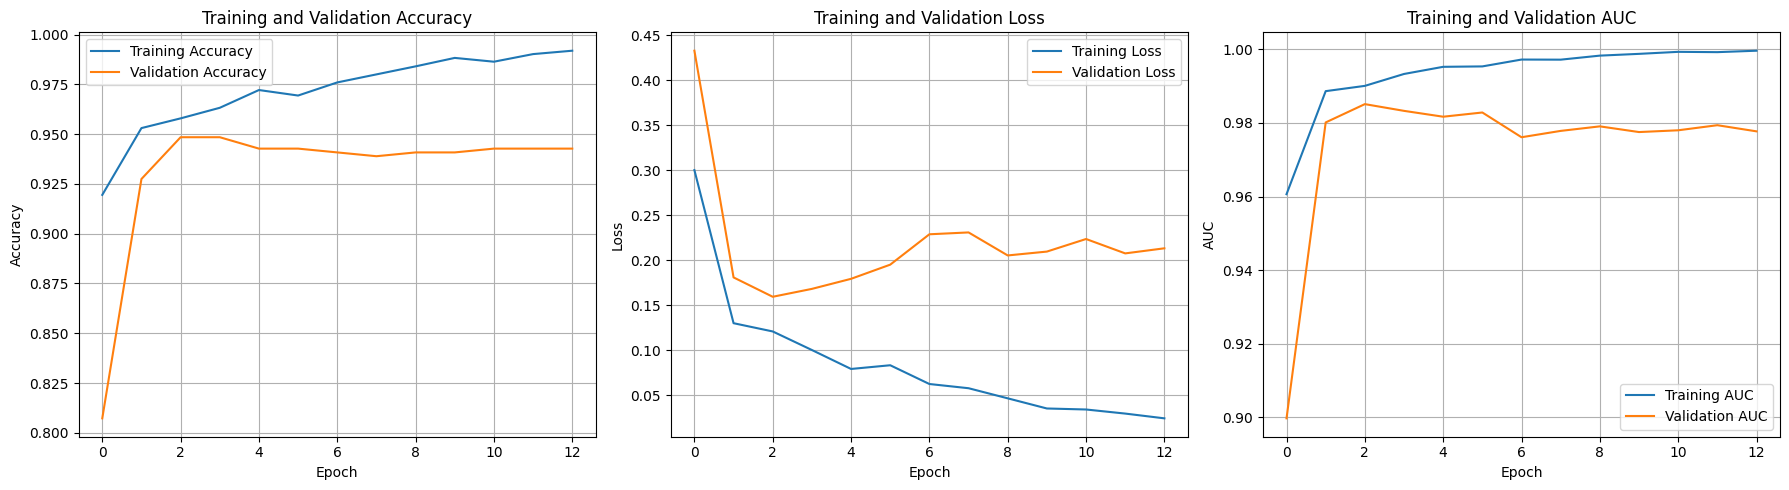

In [6]:
# Train model
history = train_model(
    model, 
    train_images, train_labels,
    val_images, val_labels,
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

# Plot training history
plot_training_history(history)

# Save final model
model.save(FINAL_MODEL_PATH)

## Evaluation

19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - AUC: 0.9213 - accuracy: 0.8405 - loss: 0.4829

2025-03-25 14:34:49.354881: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.82GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 957ms/step - AUC: 0.9212 - accuracy: 0.8397 - loss: 0.4847
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 702ms/step


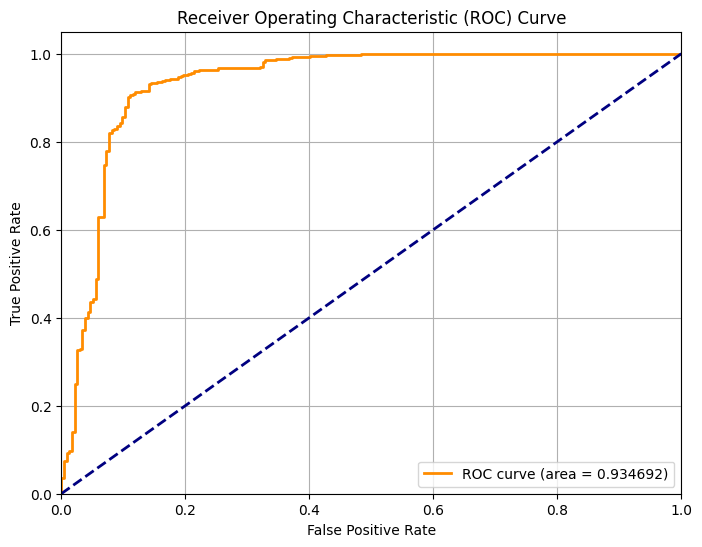

ROC AUC Score: 0.9347


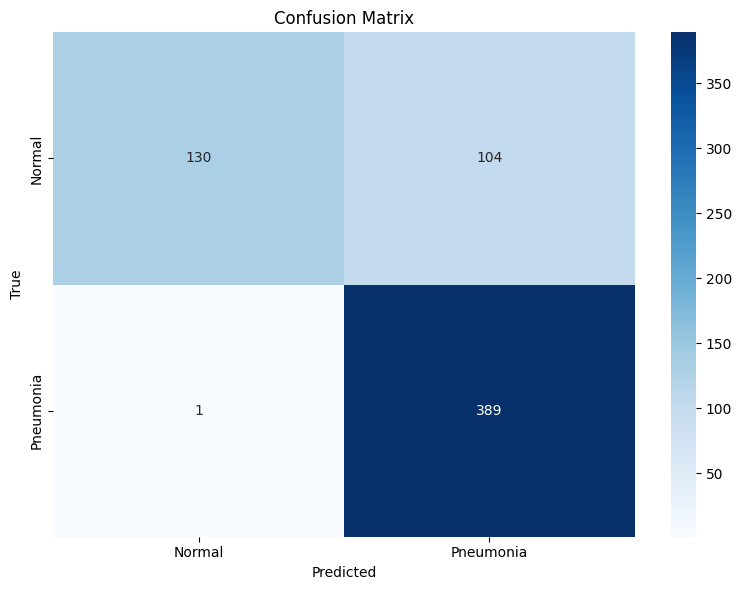

              precision    recall  f1-score   support

      Normal       0.99      0.56      0.71       234
   Pneumonia       0.79      1.00      0.88       390

    accuracy                           0.83       624
   macro avg       0.89      0.78      0.80       624
weighted avg       0.87      0.83      0.82       624



In [7]:
# Evaluate model
results = evaluate_model(model, test_images, test_labels)

# Plot results
plot_roc_curve(results['roc']['fpr'], results['roc']['tpr'], results['roc']['auc'])
plot_confusion_matrix(results['confusion_matrix'])
print(results['classification_report'])

### Comparison

In [8]:
# Load best model from training
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

# Compare with final model
results_best, results_final = compare_models(best_model, model, test_images, test_labels)

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 512ms/step - AUC: 0.9212 - accuracy: 0.8397 - loss: 0.4847
20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 732ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - AUC: 0.9212 - accuracy: 0.8397 - loss: 0.4847
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step
Best Model (in Training) vs Selected Model (through callbacks):
Test accuracy: 0.831731 vs 0.831731
Test AUC: 0.934692 vs 0.934692
